# Cloud Chamber Particle Track Classifier

This notebook detects and classifies particle tracks in cloud chamber videos using:
- **Image processing** with global thresholding and skeletonisation
- **Skeleton images** (each track skeleton resized to a fixed binary grid) as the classifier input
- **Random Forest classifier** trained directly on the skeleton-image pixels

### Particle Track Types
| Class | Label | Characteristics |
|-------|-------|----------------|
| 0 | Alpha particle | Thick, short, straight |
| 1 | Proton | Thin, long, straight |
| 2 | Electron/Positron/Muon | Thin, curved/wiggly |
| 3 | Low-energy electron | Tight spiral/curly |
| 4 | Knock-on electron | Forked track |


## Cell 1: Setup & Imports

In [2]:
# Install dependencies (uncomment if needed)
# !pip install opencv-python numpy scikit-image scikit-learn matplotlib joblib scipy

import os
import sys
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from skimage.morphology import skeletonize
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Import our local modules
import config
import track_detector
import feature_extractor
import classifier

# For inline plots
%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.dpi'] = 100

print("All imports successful!")
print(f"OpenCV version: {cv2.__version__}")
print(f"Images directory: {config.IMAGES_DIR}")
print(f"Number of annotated images: {len(glob.glob(os.path.join(config.IMAGES_DIR, '*.jpg')))}")

All imports successful!
OpenCV version: 5.0.0
Images directory: c:\Users\PC\Desktop\RSW Coursework\Y3S1\Image Processing\Jun\Skeletonisation + RandomForest\..\Images
Number of annotated images: 32


## Cell 2: Configuration & Paths

Review and optionally override configuration parameters.

In [3]:
# Display current configuration
print("=" * 60)
print("PARTICLE CLASSES")
print("=" * 60)
for idx, label in config.PARTICLE_LABELS.items():
    print(f"  Class {idx}: {label}")

print(f"\n{'=' * 60}")
print("PREPROCESSING PARAMETERS")
print("=" * 60)
print(f"  CLAHE clip limit:     {config.CLAHE_CLIP_LIMIT}")
print(f"  Denoise strength (h): {config.DENOISE_H}")
print(f"  Global threshold:     {config.GLOBAL_THRESHOLD}")
print(f"  Min contour area:     {config.MIN_CONTOUR_AREA}")
print(f"  Max contour area:     {config.MAX_CONTOUR_AREA}")

print(f"\n{'=' * 60}")
print("RANDOM FOREST PARAMETERS")
print("=" * 60)
print(f"  n_estimators:     {config.RF_N_ESTIMATORS}")
print(f"  max_depth:        {config.RF_MAX_DEPTH}")
print(f"  min_samples_split: {config.RF_MIN_SAMPLES_SPLIT}")
print(f"  min_samples_leaf:  {config.RF_MIN_SAMPLES_LEAF}")

print(f"\n{'=' * 60}")
print(f"IMAGE-LABEL MAPPING ({len(config.IMAGE_LABEL_MAP)} entries)")
print("=" * 60)
total_boxes = 0
class_counts = defaultdict(int)
for key, labels in config.IMAGE_LABEL_MAP.items():
    short_key = key.split('snapshot_')[1] if 'snapshot_' in key else key
    label_names = [config.PARTICLE_LABELS[l] for l in labels]
    print(f"  {short_key}: {label_names}")
    total_boxes += len(labels)
    for l in labels:
        class_counts[l] += 1

print(f"\nTotal annotated boxes: {total_boxes}")
print("\nClass distribution in annotations:")
for cls_id in sorted(class_counts):
    print(f"  {config.PARTICLE_LABELS[cls_id]}: {class_counts[cls_id]}")

PARTICLE CLASSES
  Class 0: Alpha
  Class 1: Proton
  Class 2: Electron/Positron/Muon
  Class 3: Low-Energy Electron
  Class 4: Knock-On Electron

PREPROCESSING PARAMETERS
  CLAHE clip limit:     3.0
  Denoise strength (h): 30
  Global threshold:     150
  Min contour area:     80
  Max contour area:     50000

RANDOM FOREST PARAMETERS
  n_estimators:     200
  max_depth:        12
  min_samples_split: 5
  min_samples_leaf:  2

IMAGE-LABEL MAPPING (32 entries)
  00.14: ['Electron/Positron/Muon']
  00.35: ['Electron/Positron/Muon']
  01.20: ['Alpha', 'Electron/Positron/Muon']
  01.25: ['Proton']
  01.26: ['Electron/Positron/Muon']
  01.34: ['Low-Energy Electron']
  01.39: ['Low-Energy Electron']
  01.44: ['Knock-On Electron']
  00.03_[2022.06.10_18.14.32]: ['Proton', 'Alpha', 'Knock-On Electron']
  00.09: ['Electron/Positron/Muon']
  00.11: ['Proton']
  00.23: ['Electron/Positron/Muon']
  00.24: ['Electron/Positron/Muon']
  00.29: ['Proton']
  00.30: ['Proton']
  00.33: ['Low-Energy Ele

## Cell 3: Training Data Extraction

Load annotated images, detect red bounding boxes, and extract track skeletons with their labels.

In [4]:
def match_image_to_labels(filename):
    """
    Match an image filename to its labels from the IMAGE_LABEL_MAP.
    Uses substring matching to handle varying filename formats.
    """
    for key, labels in config.IMAGE_LABEL_MAP.items():
        if key in filename:
            return labels
    return None


# Collect all annotated images
image_files = sorted(glob.glob(os.path.join(config.IMAGES_DIR, "*.jpg")))
print(f"Found {len(image_files)} annotated images\n")

# Extract training data
all_training_tracks = []  # List of (TrackCandidate, label)
matched_count = 0
unmatched_files = []

for img_path in image_files:
    filename = os.path.basename(img_path)
    labels = match_image_to_labels(filename)
    
    if labels is None:
        unmatched_files.append(filename)
        continue
    
    matched_count += 1
    tracks = track_detector.extract_training_data_from_image(img_path, labels)
    
    label_names = [config.PARTICLE_LABELS[l] for l in labels]
    print(f"  {filename[:60]}...")
    print(f"    Labels: {label_names}")
    print(f"    Red boxes found: {len(track_detector.detect_red_boxes(cv2.imread(img_path)))}")
    print(f"    Tracks extracted: {len(tracks)}")
    
    all_training_tracks.extend(tracks)

if unmatched_files:
    print(f"\nWarning: {len(unmatched_files)} image(s) had no label mapping:")
    for f in unmatched_files:
        print(f"  - {f}")

print(f"\n{'=' * 60}")
print(f"Total images matched: {matched_count}")
print(f"Total tracks extracted: {len(all_training_tracks)}")

# Count per class
extracted_class_counts = defaultdict(int)
for _, label in all_training_tracks:
    extracted_class_counts[label] += 1

print("\nExtracted tracks per class:")
for cls_id in sorted(extracted_class_counts):
    print(f"  {config.PARTICLE_LABELS[cls_id]}: {extracted_class_counts[cls_id]}")

Found 32 annotated images

  VID_20220609_215401_A.mp4_snapshot_00.14_[2022.06.10_12.55.2...
    Labels: ['Electron/Positron/Muon']
    Red boxes found: 1
    Tracks extracted: 7
  VID_20220609_215401_A.mp4_snapshot_00.35_[2022.06.10_12.56.3...
    Labels: ['Electron/Positron/Muon']
    Red boxes found: 1
    Tracks extracted: 7
Note: c:\Users\PC\Desktop\RSW Coursework\Y3S1\Image Processing\Jun\Skeletonisation + RandomForest\..\Images\VID_20220609_215401_A.mp4_snapshot_01.20_[2022.06.10_12.57.12].jpg — found 1 boxes but 2 labels provided. Using first 1.
  VID_20220609_215401_A.mp4_snapshot_01.20_[2022.06.10_12.57.1...
    Labels: ['Alpha', 'Electron/Positron/Muon']
    Red boxes found: 1
    Tracks extracted: 24
  VID_20220609_215401_A.mp4_snapshot_01.25_[2022.06.10_12.57.3...
    Labels: ['Proton']
    Red boxes found: 1
    Tracks extracted: 12
  VID_20220609_215401_A.mp4_snapshot_01.26_[2022.06.10_12.58.0...
    Labels: ['Electron/Positron/Muon']
    Red boxes found: 1
    Tracks ex

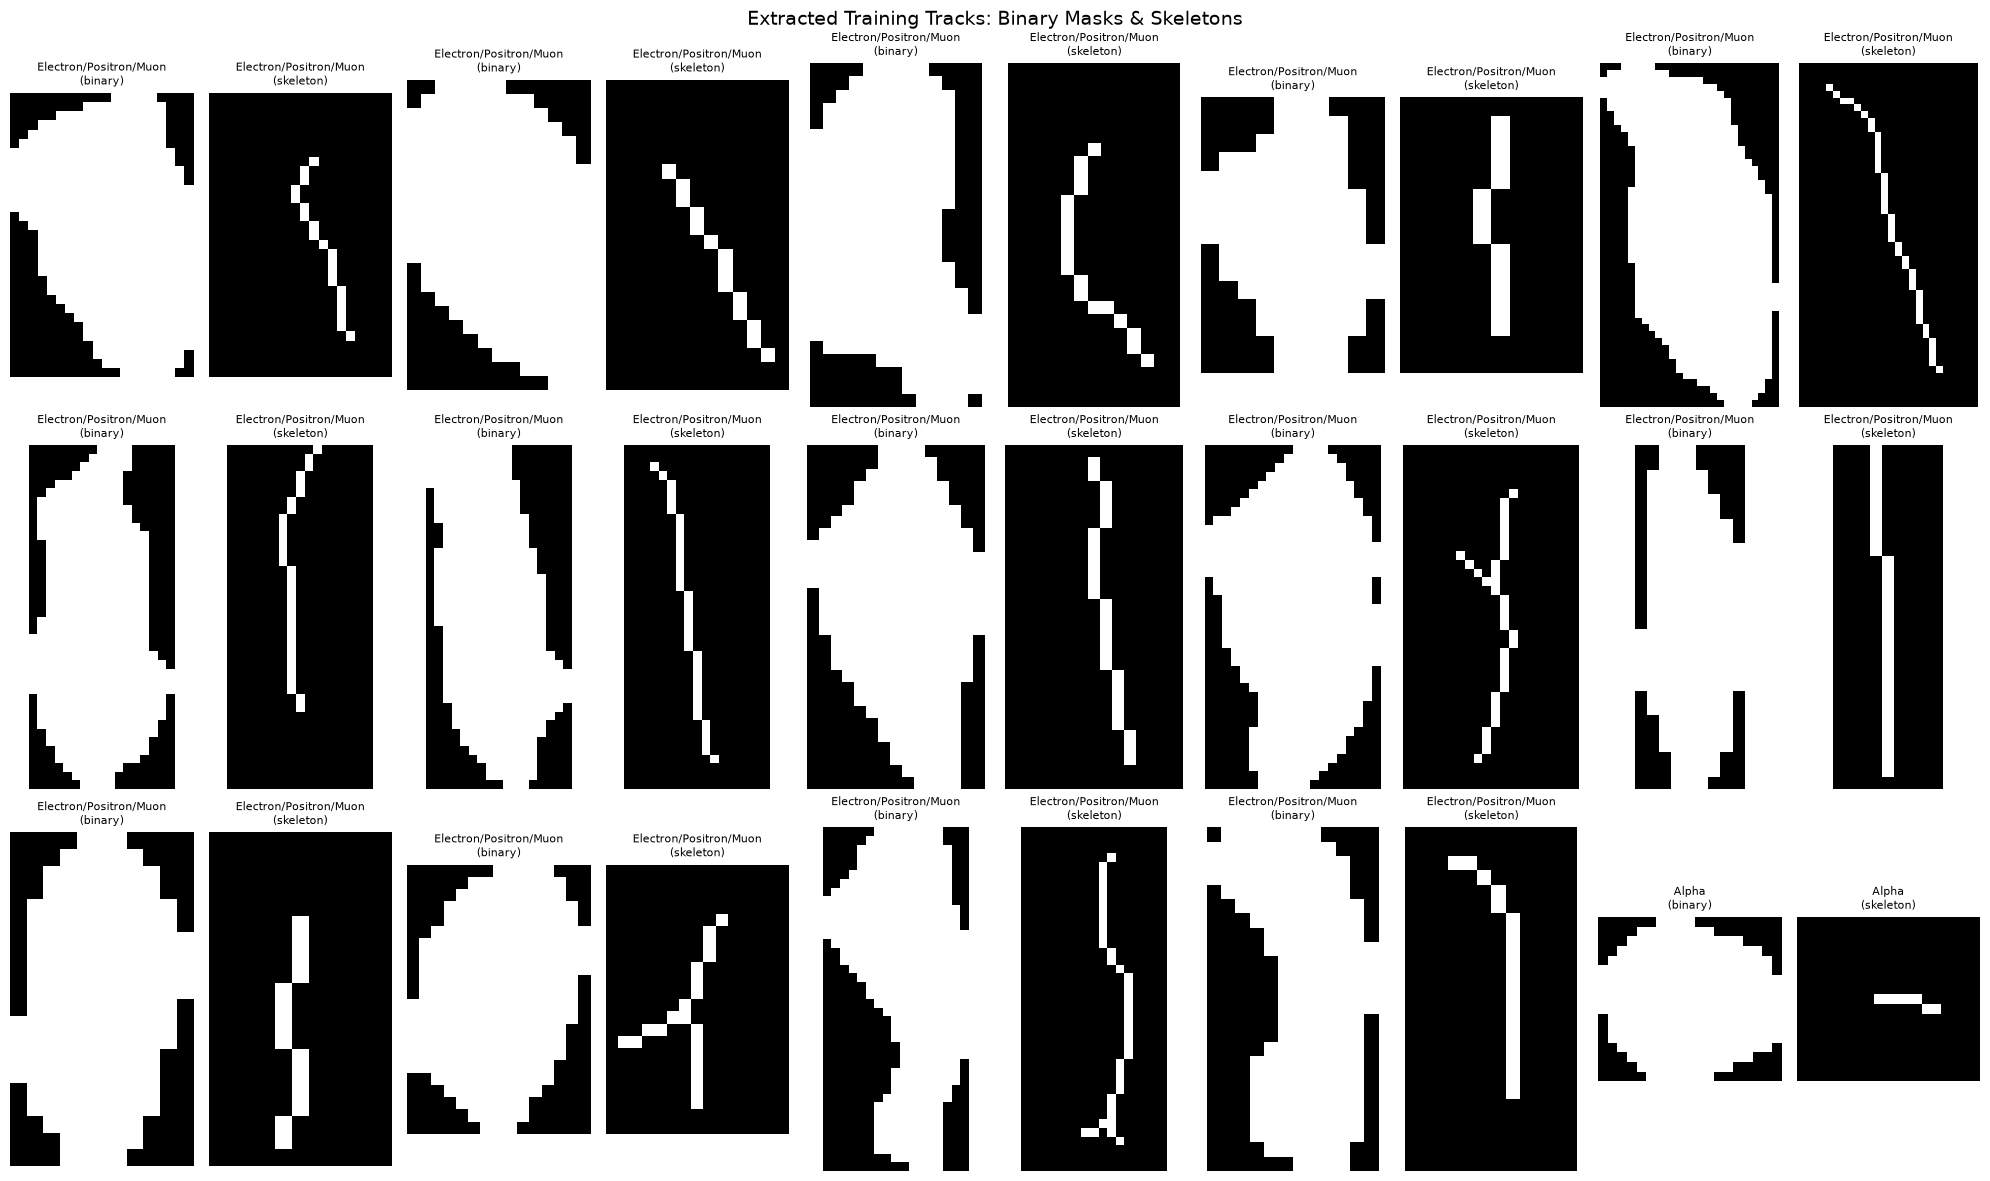

In [5]:
# Visualise some extracted training tracks
n_show = min(15, len(all_training_tracks))
if n_show > 0:
    cols = 5
    rows = (n_show + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols * 2, figsize=(20, 4 * rows))
    if rows == 1:
        axes = axes.reshape(1, -1)
    
    for i in range(n_show):
        track, label = all_training_tracks[i]
        row = i // cols
        col = (i % cols) * 2
        
        # Show binary mask
        axes[row, col].imshow(track.binary_mask, cmap='gray')
        axes[row, col].set_title(f"{config.PARTICLE_LABELS[label]}\n(binary)", fontsize=8)
        axes[row, col].axis('off')
        
        # Show skeleton
        axes[row, col + 1].imshow(track.skeleton, cmap='gray')
        axes[row, col + 1].set_title(f"{config.PARTICLE_LABELS[label]}\n(skeleton)", fontsize=8)
        axes[row, col + 1].axis('off')
    
    # Hide unused subplots
    for i in range(n_show, rows * cols):
        row = i // cols
        col = (i % cols) * 2
        if row < axes.shape[0] and col + 1 < axes.shape[1]:
            axes[row, col].axis('off')
            axes[row, col + 1].axis('off')
    
    plt.suptitle("Extracted Training Tracks: Binary Masks & Skeletons", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("No tracks were extracted. Check preprocessing parameters.")

## Cell 4: Skeleton Image Vectorisation

Convert each detected track skeleton into the fixed-size binary pixel vector
that the Random Forest is trained on.


In [6]:
# Convert each training skeleton into a fixed-size binary image vector.
# These pixels ARE the features the Random Forest learns from.
X_real = []
y_real = []

for track, label in all_training_tracks:
    try:
        vector = feature_extractor.skeleton_to_vector(track.skeleton)
        if np.any(np.isnan(vector)) or np.any(np.isinf(vector)):
            continue
        X_real.append(vector)
        y_real.append(label)
    except Exception as e:
        print(f"  Skeleton vectorisation failed for a {config.PARTICLE_LABELS[label]} track: {e}")

X_real = np.array(X_real)
y_real = np.array(y_real)

img_h, img_w = config.SKELETON_IMG_SIZE

print(f"Skeleton image grid:   {img_h} x {img_w}  ->  {img_h * img_w} pixels/features")
print(f"Feature matrix shape:  {X_real.shape}")
print(f"Label vector shape:    {y_real.shape}")

# Per-class counts of the real skeleton images
print(f"\n{'=' * 60}")
print("REAL SKELETON SAMPLES PER CLASS")
print("=" * 60)
if X_real.shape[0] > 0:
    for cls_id in sorted(np.unique(y_real)):
        n = int((y_real == cls_id).sum())
        print(f"  {config.PARTICLE_LABELS[cls_id]:<25} {n}")
    missing = [config.PARTICLE_LABELS[c] for c in range(5) if c not in np.unique(y_real)]
    if missing:
        print(f"\n  Warning: no real skeletons for: {missing}")
        print("  (image-based training cannot synthesise classes with zero real samples)")
else:
    print("  No real skeletons extracted — check detection parameters.")


Skeleton image grid:   32 x 32  ->  1024 pixels/features
Feature matrix shape:  (698, 1024)
Label vector shape:    (698,)

REAL SKELETON SAMPLES PER CLASS
  Alpha                     154
  Proton                    281
  Electron/Positron/Muon    165
  Low-Energy Electron       44
  Knock-On Electron         54


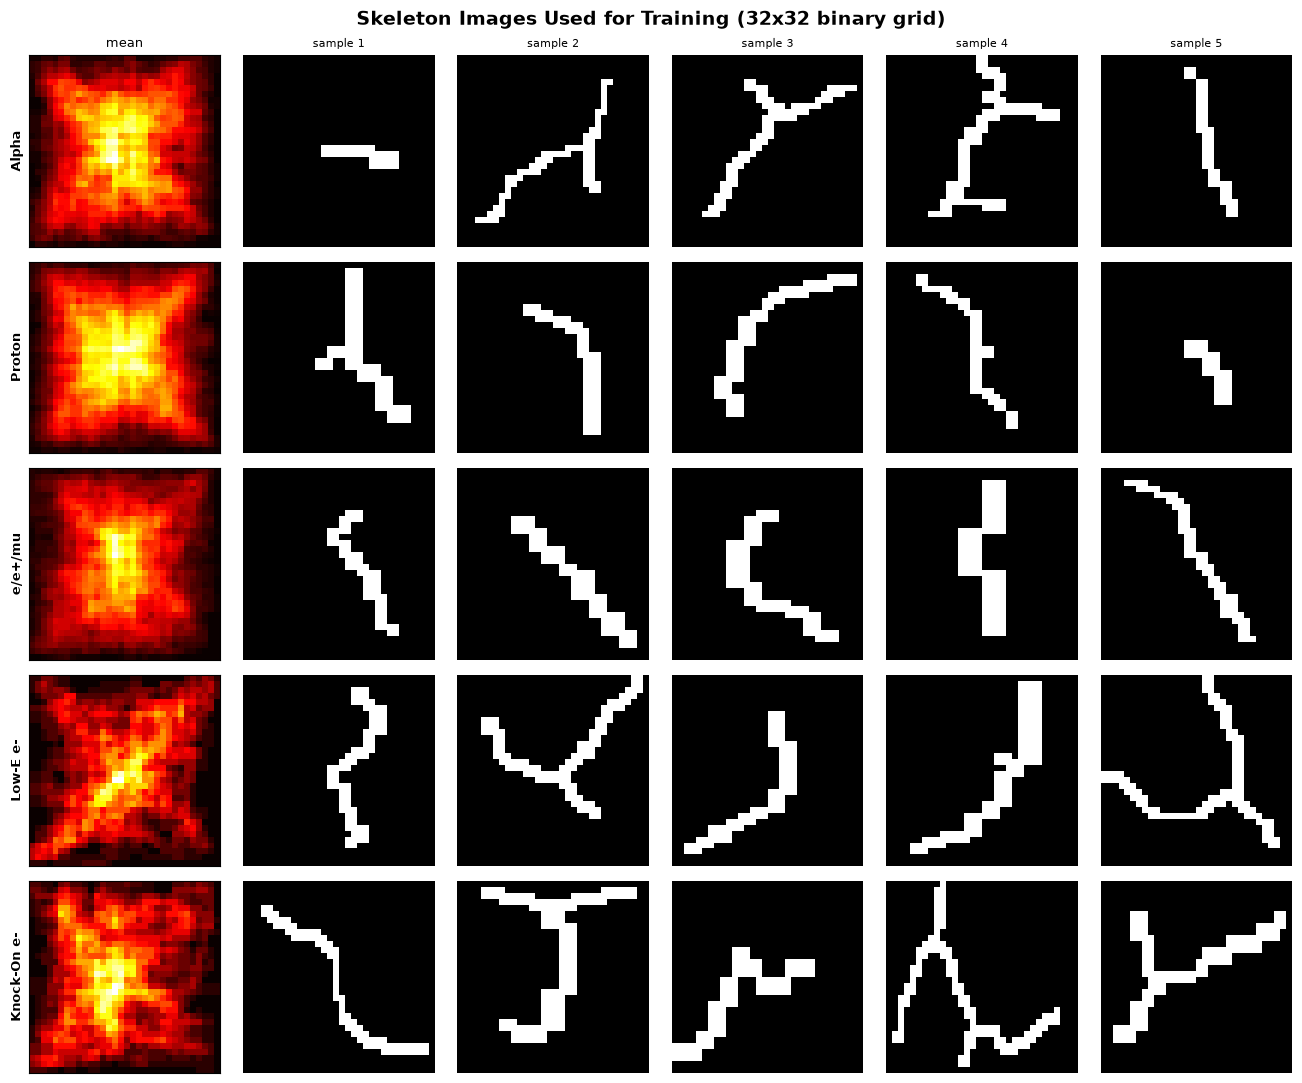

In [7]:
# Visualise the skeleton IMAGES the classifier is trained on.
# Left column: average skeleton per class (the "template" the RF sees).
# Right columns: individual real skeleton samples for that class.
if X_real.shape[0] > 0:
    img_h, img_w = config.SKELETON_IMG_SIZE
    unique_classes = sorted(np.unique(y_real))
    n_samples_show = 5

    fig, axes = plt.subplots(
        len(unique_classes), n_samples_show + 1,
        figsize=(2.2 * (n_samples_show + 1), 2.2 * len(unique_classes))
    )
    axes = np.atleast_2d(axes)

    for row, cls_id in enumerate(unique_classes):
        mask = y_real == cls_id
        class_imgs = X_real[mask].reshape(-1, img_h, img_w)

        # Mean skeleton image (average occupancy of each pixel)
        mean_img = class_imgs.mean(axis=0)
        axes[row, 0].imshow(mean_img, cmap='hot')
        axes[row, 0].set_ylabel(config.PARTICLE_SHORT_LABELS[cls_id],
                                fontsize=9, fontweight='bold')
        axes[row, 0].set_title('mean' if row == 0 else '', fontsize=9)
        axes[row, 0].set_xticks([])
        axes[row, 0].set_yticks([])

        # Individual samples
        for s in range(n_samples_show):
            ax = axes[row, s + 1]
            if s < class_imgs.shape[0]:
                ax.imshow(class_imgs[s], cmap='gray')
            if row == 0:
                ax.set_title(f'sample {s + 1}', fontsize=8)
            ax.axis('off')

    plt.suptitle(
        f"Skeleton Images Used for Training ({img_h}x{img_w} binary grid)",
        fontsize=14, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()
else:
    print("No skeleton images to visualise.")


## Cell 5: Skeleton Image Augmentation

Real annotated skeletons are scarce, so we augment each real skeleton **image**
with label-preserving transformations (rotations, flips, small shifts and mild
scaling). This grows every class to a balanced target count while keeping the
representation as binary skeleton pixels — the same representation the Random
Forest is trained and evaluated on.


In [8]:
def _augment_skeleton_image(img, rng):
    """
    Apply one random label-preserving transform to a single binary skeleton
    image and return a re-binarised skeleton image of the same size.
    """
    h, w = img.shape
    out = (img > 0).astype(np.uint8) * 255

    # Random rotation
    angle = rng.uniform(-25, 25)
    scale = rng.uniform(0.85, 1.15)
    M = cv2.getRotationMatrix2D((w / 2, h / 2), angle, scale)
    # Random small translation
    M[0, 2] += rng.uniform(-0.12 * w, 0.12 * w)
    M[1, 2] += rng.uniform(-0.12 * h, 0.12 * h)
    out = cv2.warpAffine(out, M, (w, h), flags=cv2.INTER_NEAREST, borderValue=0)

    # Random flips
    if rng.rand() < 0.5:
        out = cv2.flip(out, 1)  # horizontal
    if rng.rand() < 0.3:
        out = cv2.flip(out, 0)  # vertical

    # Re-skeletonise so line thickness stays 1px after interpolation
    thinned = skeletonize(out > 0)
    return thinned.astype(np.float32).flatten()


def augment_skeleton_images(X_real, y_real, target_per_class=200, random_state=42):
    """
    Grow each class up to ``target_per_class`` skeleton-image samples using
    random rotations, flips, shifts and scaling of the real skeleton images.

    Classes with zero real samples cannot be augmented and are skipped.
    """
    rng = np.random.RandomState(random_state)
    X_aug, y_aug = [], []

    for cls_id in range(5):
        mask = y_real == cls_id
        n_real = int(mask.sum())
        if n_real == 0:
            continue

        real_imgs = X_real[mask].reshape(-1, *config.SKELETON_IMG_SIZE)
        n_needed = max(target_per_class - n_real, 0)
        for _ in range(n_needed):
            base = real_imgs[rng.randint(n_real)]
            X_aug.append(_augment_skeleton_image(base, rng))
            y_aug.append(cls_id)

    if len(X_aug) == 0:
        return np.empty((0, X_real.shape[1])), np.empty((0,), dtype=int)
    return np.array(X_aug), np.array(y_aug)


# Generate augmented skeleton images
X_aug, y_aug = augment_skeleton_images(
    X_real, y_real,
    target_per_class=config.SYNTHETIC_SAMPLES_PER_CLASS,
)

# Combine real + augmented skeleton images
X_combined = np.vstack([X_real, X_aug]) if X_real.shape[0] > 0 else X_aug
y_combined = np.concatenate([y_real, y_aug]) if y_real.shape[0] > 0 else y_aug

print(f"Real skeleton images:      {X_real.shape[0]}")
print(f"Augmented skeleton images: {X_aug.shape[0]}")
print(f"Combined total:            {X_combined.shape[0]}")
print(f"Pixels per image:          {X_combined.shape[1] if X_combined.shape[0] else 0}")

print("\nCombined class distribution:")
for cls_id in sorted(np.unique(y_combined)):
    n = int((y_combined == cls_id).sum())
    n_real = int((y_real == cls_id).sum()) if y_real.shape[0] > 0 else 0
    print(f"  {config.PARTICLE_LABELS[cls_id]}: {n} ({n_real} real + {n - n_real} augmented)")


Real skeleton images:      698
Augmented skeleton images: 383
Combined total:            1081
Pixels per image:          1024

Combined class distribution:
  Alpha: 200 (154 real + 46 augmented)
  Proton: 281 (281 real + 0 augmented)
  Electron/Positron/Muon: 200 (165 real + 35 augmented)
  Low-Energy Electron: 200 (44 real + 156 augmented)
  Knock-On Electron: 200 (54 real + 146 augmented)


## Cell 6: Model Training & Evaluation

Train the Random Forest classifier and evaluate its performance.

In [9]:
# Train the model on skeleton-image pixel vectors
model, cv_accuracy, cv_std, report = classifier.train_model(
    X_combined, y_combined, cv_folds=5
)

print(f"{'=' * 60}")
print(f"CROSS-VALIDATION RESULTS")
print(f"{'=' * 60}")
print(f"Accuracy: {cv_accuracy:.4f} (+/- {cv_std:.4f})")
print(f"\n{report}")

# Pixel importance: reshape the RF feature importances back into the
# skeleton image grid so we can see which skeleton regions matter most.
img_h, img_w = config.SKELETON_IMG_SIZE
importances = model.feature_importances_
importance_img = importances.reshape(img_h, img_w)

print(f"{'=' * 60}")
print(f"PIXEL IMPORTANCE SUMMARY")
print(f"{'=' * 60}")
print(f"  Total pixel features: {importances.size}")
print(f"  Max pixel importance: {importances.max():.5f}")
print(f"  Mean pixel importance: {importances.mean():.5f}")


CROSS-VALIDATION RESULTS
Accuracy: 0.3589 (+/- 0.0176)

                        precision    recall  f1-score   support

                 Alpha       1.00      0.88      0.94       200
                Proton       0.99      1.00      0.99       281
Electron/Positron/Muon       0.99      0.94      0.97       200
   Low-Energy Electron       0.80      0.99      0.89       200
     Knock-On Electron       0.98      0.92      0.95       200

              accuracy                           0.95      1081
             macro avg       0.95      0.94      0.95      1081
          weighted avg       0.96      0.95      0.95      1081

PIXEL IMPORTANCE SUMMARY
  Total pixel features: 1024
  Max pixel importance: 0.00523
  Mean pixel importance: 0.00098


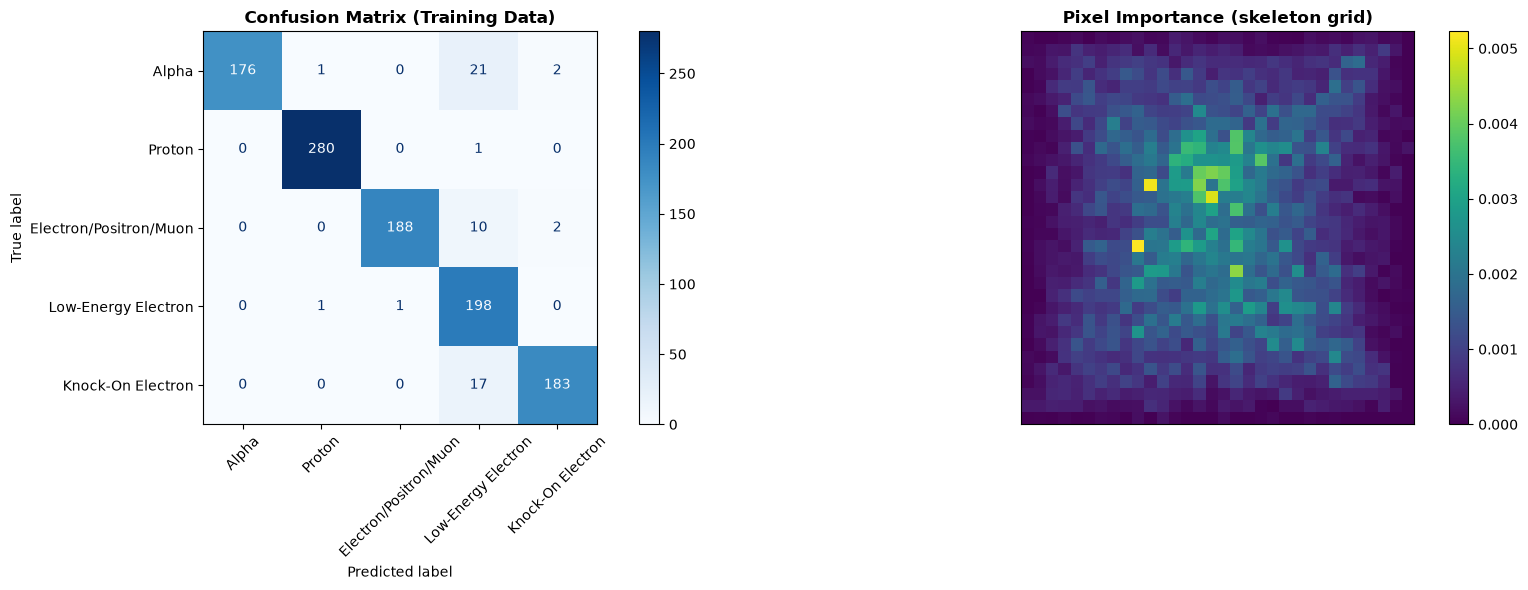

Model saved to c:\Users\PC\Desktop\RSW Coursework\Y3S1\Image Processing\Jun\Skeletonisation + RandomForest\trained_model.pkl

Model saved to c:\Users\PC\Desktop\RSW Coursework\Y3S1\Image Processing\Jun\Skeletonisation + RandomForest\trained_model.pkl


In [10]:
# Confusion matrix
cm, cm_labels = classifier.get_confusion_matrix(model, X_combined, y_combined)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cm_labels)
disp.plot(ax=axes[1 - 1], cmap='Blues', values_format='d')
axes[0].set_title('Confusion Matrix (Training Data)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Pixel-importance heatmap over the skeleton grid
im = axes[1].imshow(importance_img, cmap='viridis')
axes[1].set_title('Pixel Importance (skeleton grid)', fontsize=12, fontweight='bold')
axes[1].set_xticks([])
axes[1].set_yticks([])
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# Save the trained model
classifier.save_model(model)
print(f"\nModel saved to {config.MODEL_PATH}")


## Cell 7: Video Processing Pipeline

Process a cloud chamber video: detect tracks, classify them, and save an annotated output video.

In [11]:
def process_video(input_path, output_path, model,
                  skip_frames=1, max_frames=None, show_progress=True,
                  save_skeleton_video=True):
    """
    Process a cloud chamber video and output an annotated version.

    Each processed frame is first preprocessed into a skeletonised binary
    representation. Track candidates are detected and every candidate is
    classified from its skeleton image (the representation the Random Forest
    was trained on).

    Parameters
    ----------
    input_path : str
        Path to the input video file.
    output_path : str
        Path for the output annotated video.
    model : RandomForestClassifier
        Trained classifier model.
    skip_frames : int
        Process every Nth frame (1 = every frame).
    max_frames : int or None
        Maximum number of frames to process (None = all).
    show_progress : bool
        Print progress updates.
    save_skeleton_video : bool
        Also write a companion video of the skeletonised frames.

    Returns
    -------
    stats : dict
        Processing statistics.
    """
    cap = cv2.VideoCapture(input_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {input_path}")

    # Video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    print(f"Video: {input_path}")
    print(f"  Resolution: {width}x{height}")
    print(f"  FPS: {fps:.1f}")
    print(f"  Total frames: {total_frames}")
    print(f"  Duration: {total_frames/fps:.1f}s")

    # Output writer
    fourcc = cv2.VideoWriter_fourcc(*config.VIDEO_CODEC)
    out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

    if not out.isOpened():
        raise ValueError(f"Could not create output video: {output_path}")

    # Optional companion skeleton video
    skel_out = None
    if save_skeleton_video:
        skel_path = os.path.splitext(output_path)[0] + "_skeleton.mp4"
        skel_out = cv2.VideoWriter(skel_path, fourcc, fps, (width, height))

    # Background subtractor
    bg_subtractor = cv2.createBackgroundSubtractorMOG2(
        history=config.BG_HISTORY,
        varThreshold=config.BG_THRESHOLD,
        detectShadows=config.BG_DETECT_SHADOWS,
    )

    # Statistics
    stats = {
        'total_frames': 0,
        'processed_frames': 0,
        'total_tracks': 0,
        'class_counts': defaultdict(int),
        'sample_frames': [],       # Annotated frames for preview
        'sample_skeletons': [],    # Matching skeleton frames for preview
    }

    frame_idx = 0

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        stats['total_frames'] += 1
        frame_idx += 1

        if max_frames and stats['processed_frames'] >= max_frames:
            # Still write remaining frames unannotated
            out.write(frame)
            continue

        # Skip frames for faster processing
        if frame_idx % skip_frames != 0:
            out.write(frame)
            continue

        stats['processed_frames'] += 1
        annotated_frame = frame.copy()

        # Preprocess the frame into its skeletonised representation first
        skeleton_frame = track_detector.skeletonise_frame(frame, bg_subtractor)
        skeleton_bgr = cv2.cvtColor(skeleton_frame, cv2.COLOR_GRAY2BGR)

        # Detect track candidates (each candidate carries its own skeleton)
        tracks = track_detector.extract_tracks_from_frame(frame, bg_subtractor)

        # Classify each track from its skeleton image and annotate
        for track in tracks:
            try:
                # Skeletonised track image -> flattened binary pixel vector
                features = feature_extractor.skeleton_to_vector(track.skeleton)

                if np.any(np.isnan(features)) or np.any(np.isinf(features)):
                    continue

                # Classify
                pred_class, probabilities = classifier.predict_track(model, features)
                confidence = probabilities.get(pred_class, 0.0)

                # Get display properties
                label = config.PARTICLE_SHORT_LABELS[pred_class]
                color = config.PARTICLE_COLORS[pred_class]
                x, y_pos, w, h = track.bbox

                # Draw bounding box on both the annotated and skeleton frames
                cv2.rectangle(
                    annotated_frame,
                    (x, y_pos), (x + w, y_pos + h),
                    color, 2
                )
                cv2.rectangle(
                    skeleton_bgr,
                    (x, y_pos), (x + w, y_pos + h),
                    color, 2
                )

                # Draw label with confidence
                text = f"{label} ({confidence:.0%})"
                text_size = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)[0]

                # Background rectangle for text readability
                cv2.rectangle(
                    annotated_frame,
                    (x, y_pos - text_size[1] - 8),
                    (x + text_size[0] + 4, y_pos),
                    color, -1  # Filled
                )
                cv2.putText(
                    annotated_frame, text,
                    (x + 2, y_pos - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5,
                    (255, 255, 255), 1, cv2.LINE_AA
                )

                stats['total_tracks'] += 1
                stats['class_counts'][pred_class] += 1

            except Exception as e:
                continue

        # Write annotated frame (and skeleton frame)
        out.write(annotated_frame)
        if skel_out is not None:
            skel_out.write(skeleton_bgr)

        # Save sample frames for preview (every 10% of video)
        if len(tracks) > 0 and len(stats['sample_frames']) < 8:
            if frame_idx % max(total_frames // 8, 1) == 0 or len(stats['sample_frames']) == 0:
                # Convert BGR to RGB for matplotlib
                stats['sample_frames'].append(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
                stats['sample_skeletons'].append(cv2.cvtColor(skeleton_bgr, cv2.COLOR_BGR2RGB))

        # Progress
        if show_progress and frame_idx % 100 == 0:
            pct = frame_idx / total_frames * 100 if total_frames > 0 else 0
            print(f"  Frame {frame_idx}/{total_frames} ({pct:.1f}%) — "
                  f"{stats['total_tracks']} tracks detected so far")

    cap.release()
    out.release()
    if skel_out is not None:
        skel_out.release()

    print(f"\n{'=' * 60}")
    print(f"PROCESSING COMPLETE")
    print(f"{'=' * 60}")
    print(f"Output saved to: {output_path}")
    if skel_out is not None:
        print(f"Skeleton video saved to: {os.path.splitext(output_path)[0] + '_skeleton.mp4'}")
    print(f"Frames processed: {stats['processed_frames']}/{stats['total_frames']}")
    print(f"Total tracks detected: {stats['total_tracks']}")
    print(f"\nDetections per class:")
    for cls_id in sorted(stats['class_counts']):
        print(f"  {config.PARTICLE_LABELS[cls_id]}: {stats['class_counts'][cls_id]}")

    return stats


In [12]:
# ============================================================
# SET YOUR VIDEO PATH HERE
# ============================================================
VIDEO_INPUT = r"C:/Users/PC/Desktop/RSW Coursework/Y3S1/Image Processing/Jun/Videos/test_vid_cropped.mp4"
VIDEO_OUTPUT = os.path.join(config.BASE_DIR, "output_annotated.mp4")

# Optional: load a previously saved model instead of using the
# one trained above
# model = classifier.load_model()

# Process the video
if os.path.exists(VIDEO_INPUT):
    stats = process_video(
        input_path=VIDEO_INPUT,
        output_path=VIDEO_OUTPUT,
        model=model,
        skip_frames=1,      # Process every frame (set higher for speed)
        max_frames=None,    # Process all frames (set a number to limit)
    )
else:
    print(f"Video not found: {VIDEO_INPUT}")
    print("Please update VIDEO_INPUT with the correct path to your cloud chamber video.")
    stats = None

Video: C:/Users/PC/Desktop/RSW Coursework/Y3S1/Image Processing/Jun/Videos/test_vid_cropped.mp4
  Resolution: 1080x1722
  FPS: 29.7
  Total frames: 4299
  Duration: 144.6s
  Frame 100/4299 (2.3%) — 1 tracks detected so far
  Frame 200/4299 (4.7%) — 1 tracks detected so far
  Frame 300/4299 (7.0%) — 1 tracks detected so far
  Frame 400/4299 (9.3%) — 10 tracks detected so far
  Frame 500/4299 (11.6%) — 34 tracks detected so far
  Frame 600/4299 (14.0%) — 34 tracks detected so far
  Frame 700/4299 (16.3%) — 35 tracks detected so far
  Frame 800/4299 (18.6%) — 82 tracks detected so far
  Frame 900/4299 (20.9%) — 82 tracks detected so far
  Frame 1000/4299 (23.3%) — 82 tracks detected so far
  Frame 1100/4299 (25.6%) — 82 tracks detected so far
  Frame 1200/4299 (27.9%) — 110 tracks detected so far
  Frame 1300/4299 (30.2%) — 112 tracks detected so far
  Frame 1400/4299 (32.6%) — 112 tracks detected so far
  Frame 1500/4299 (34.9%) — 118 tracks detected so far
  Frame 1600/4299 (37.2%) — 11

## Cell 8: Results Preview

Display sample annotated frames and detection statistics.

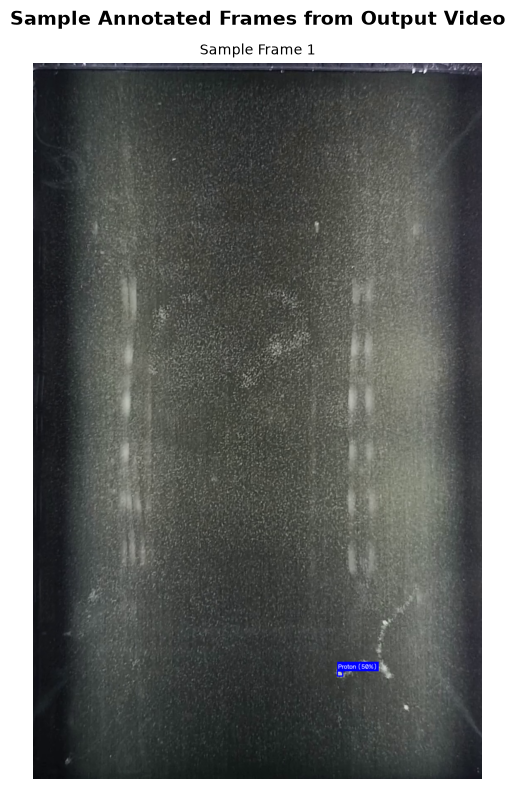

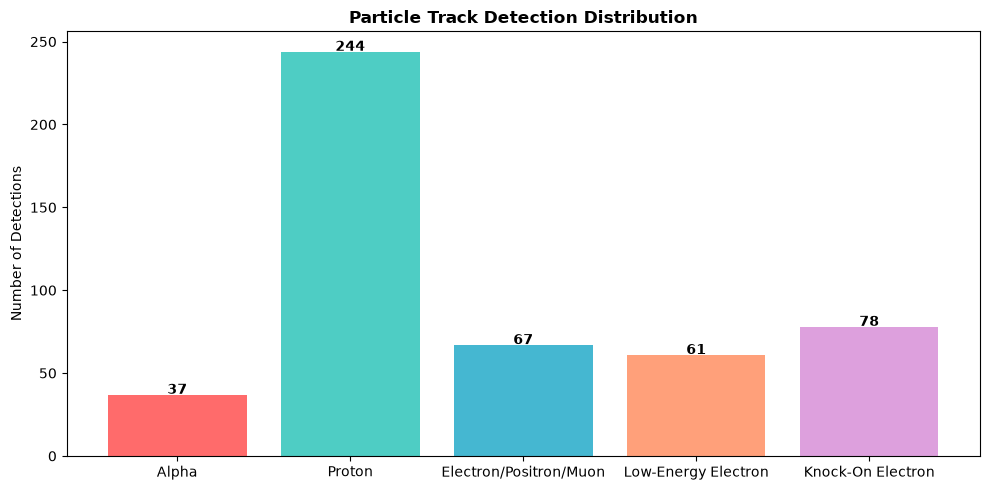

In [13]:
if stats is not None and len(stats.get('sample_frames', [])) > 0:
    n_samples = len(stats['sample_frames'])
    cols = min(4, n_samples)
    rows = (n_samples + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 8 * rows))
    if n_samples == 1:
        axes = np.array([axes])
    axes = np.atleast_2d(axes)
    
    for i, frame_rgb in enumerate(stats['sample_frames']):
        r, c = divmod(i, cols)
        axes[r, c].imshow(frame_rgb)
        axes[r, c].set_title(f'Sample Frame {i+1}', fontsize=10)
        axes[r, c].axis('off')
    
    # Hide unused subplots
    for i in range(n_samples, rows * cols):
        r, c = divmod(i, cols)
        if r < axes.shape[0] and c < axes.shape[1]:
            axes[r, c].axis('off')
    
    plt.suptitle('Sample Annotated Frames from Output Video', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Detection statistics chart
    if stats['total_tracks'] > 0:
        fig, ax = plt.subplots(figsize=(10, 5))
        class_names = [config.PARTICLE_LABELS[c] for c in sorted(stats['class_counts'])]
        counts = [stats['class_counts'][c] for c in sorted(stats['class_counts'])]
        colors_pie = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A', '#DDA0DD']
        
        bars = ax.bar(class_names, counts, 
                      color=[colors_pie[c] for c in sorted(stats['class_counts'])])
        ax.set_ylabel('Number of Detections')
        ax.set_title('Particle Track Detection Distribution', 
                     fontsize=12, fontweight='bold')
        
        # Add count labels on bars
        for bar, count in zip(bars, counts):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    str(count), ha='center', fontweight='bold')
        
        plt.tight_layout()
        plt.show()
else:
    print("No video has been processed yet.")
    print("Set VIDEO_INPUT in the cell above and run it to process a video.")
    print("\nYou can also test the classifier on individual images:")

Testing on: VID_20220609_221024_A.mp4_snapshot_00.33_[2022.06.10_18.19.46].jpg
Detected 4 tracks in VID_20220609_221024_A.mp4_snapshot_00.33_[2022.06.10_18.19.46].jpg
  Track at (0,1858): Proton (29.4%)
  Track at (498,1854): Proton (37.2%)
  Track at (151,1811): Proton (24.5%)
  Track at (390,1808): Electron/Positron/Muon (37.2%)


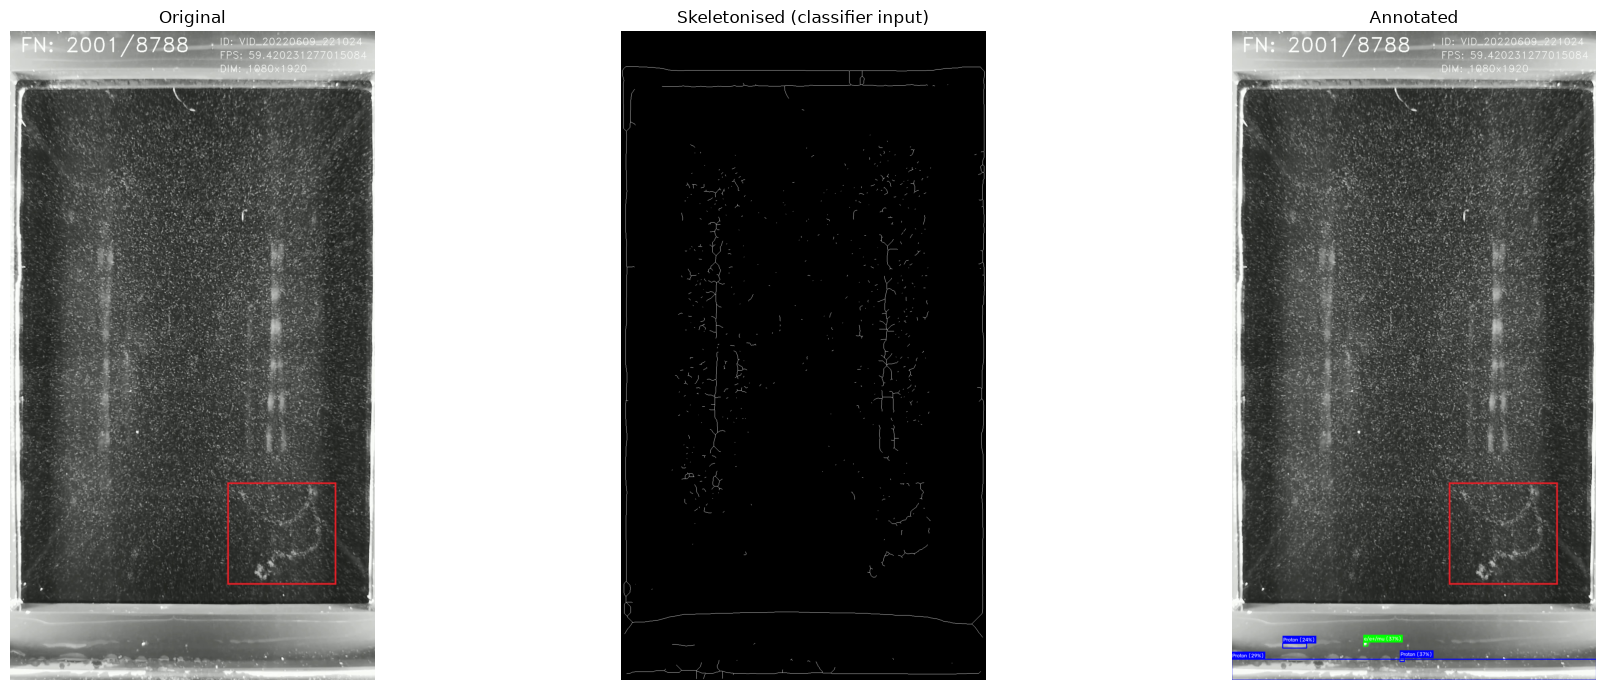

In [14]:
# =============================================================
# BONUS: Test on a single image (useful for quick verification)
# =============================================================
def classify_single_image(image_path, model, show_steps=True):
    """
    Run the full skeleton-image pipeline on a single image and display results.
    """
    image = cv2.imread(image_path)
    if image is None:
        print(f"Could not load: {image_path}")
        return

    # Skeletonise the whole image (no background subtraction for stills)
    skeleton_frame = track_detector.skeletonise_frame(image, bg_subtractor=None)
    skeleton_bgr = cv2.cvtColor(skeleton_frame, cv2.COLOR_GRAY2BGR)

    # Detect tracks (each candidate carries its own skeleton)
    tracks = track_detector.extract_tracks_from_frame(image, bg_subtractor=None)
    print(f"Detected {len(tracks)} tracks in {os.path.basename(image_path)}")

    # Annotate
    annotated = image.copy()
    for track in tracks:
        try:
            # Classify from the skeleton image vector
            features = feature_extractor.skeleton_to_vector(track.skeleton)
            if np.any(np.isnan(features)) or np.any(np.isinf(features)):
                continue

            pred_class, probabilities = classifier.predict_track(model, features)
            confidence = probabilities.get(pred_class, 0.0)
            label = config.PARTICLE_SHORT_LABELS[pred_class]
            color = config.PARTICLE_COLORS[pred_class]
            x, y, w, h = track.bbox

            for canvas in (annotated, skeleton_bgr):
                cv2.rectangle(canvas, (x, y), (x+w, y+h), color, 2)
            text = f"{label} ({confidence:.0%})"
            text_size = cv2.getTextSize(text, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 1)[0]
            cv2.rectangle(annotated, (x, y-text_size[1]-8), (x+text_size[0]+4, y), color, -1)
            cv2.putText(annotated, text, (x+2, y-5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,255,255), 1, cv2.LINE_AA)

            print(f"  Track at ({x},{y}): {config.PARTICLE_LABELS[pred_class]} ({confidence:.1%})")
        except Exception as e:
            print(f"  Error: {e}")

    if show_steps:
        # Show original, skeletonised, and annotated
        fig, axes = plt.subplots(1, 3, figsize=(20, 7))
        axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        axes[0].set_title('Original')
        axes[0].axis('off')
        axes[1].imshow(skeleton_frame, cmap='gray')
        axes[1].set_title('Skeletonised (classifier input)')
        axes[1].axis('off')
        axes[2].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
        axes[2].set_title('Annotated')
        axes[2].axis('off')
        plt.tight_layout()
        plt.show()

    return annotated


# Test on one of the annotated images
test_images = sorted(glob.glob(os.path.join(config.IMAGES_DIR, "*221024*.jpg")))
if test_images:
    # Pick an image with clear tracks
    test_img = test_images[min(7, len(test_images)-1)]  # 00.34 snapshot
    print(f"Testing on: {os.path.basename(test_img)}")
    _ = classify_single_image(test_img, model)
else:
    print("No test images found.")
